### Notebook for analysis of FL and OD data for LEMOS experiments

In [1]:
## import here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from scipy.stats import ttest_ind

In [2]:
## import the datafiles 

FL_data = pd.read_csv('fl.csv')
OD_data = pd.read_csv('od.csv')
N_size = len(FL_data)

# Replace 'OVERFLW' with 100000 in all columns of FL_data and OD_data
FL_data.replace("OVRFLW", int(100000), inplace = True)
OD_data.replace("OVRFLW", int(1), inplace = True)

FL_data = FL_data.apply(pd.to_numeric, errors='coerce')
# print(FL_data.dtypes)

In [3]:
## Process the data files 
# define what samples are in what well
neg_wells = ['H11']
green_constant = ['F9', 'E11', 'F11']
green_constant_adj_red = ['A9', 'C9', 'E9', 'D11'] # should discard B11 data since the well had some defect.
red_constant = ['B9', 'D9', 'A11', 'C11']
dark_constant = ['G9', 'H9', 'G11']

# Sequence of control wells:
ctrl_wells = ['A11', 'B11', 'C11', 'D11', 'E11', 'F11', 'G11', 'H11',
              'H9',  'G9',  'F9',  'E9',  'D9',  'C9',  'B9',  'A9']



## Sort the OD data
blank_OD_array = np.array([0.17, 0.27, 0.17, 0.2, 0.18, 0.18, 0.16, 0.07,
                          0.13, 0.13, 0.13, 0.12, 0.13, 0.15, 0.12, 0.15]) # replace this array with the array in the python code
# blank_OD_array = np.mean(blank_OD_array) * np.ones(16) 

# map each control well to its corresponding OD value
well_to_blank_OD = dict(zip(ctrl_wells, blank_OD_array))

# pull values by well identity
blank_green = [well_to_blank_OD[w] for w in green_constant]
blank_green_adj_red = [well_to_blank_OD[w] for w in green_constant_adj_red]
blank_red = [well_to_blank_OD[w] for w in red_constant]
blank_dark = [well_to_blank_OD[w] for w in dark_constant]
blank_neg = [well_to_blank_OD[w] for w in neg_wells]




neg_ctrl_OD = np.zeros((len(neg_wells),N_size))
for i in range(len(neg_wells)):
    neg_ctrl_OD[i,:] = OD_data[neg_wells[i]].to_numpy() - blank_neg[i]

green_constant_OD = np.zeros((len(green_constant),N_size))
for i in range(len(green_constant)):
    green_constant_OD[i,:] = OD_data[green_constant[i]].to_numpy() - blank_green[i]

green_constant_adj_red_OD = np.zeros((len(green_constant_adj_red),N_size))
for i in range(len(green_constant_adj_red)):
    green_constant_adj_red_OD[i,:] = OD_data[green_constant_adj_red[i]].to_numpy() - blank_green_adj_red[i]

red_constant_OD = np.zeros((len(red_constant),N_size))
for i in range(len(red_constant)):
    red_constant_OD[i,:] = OD_data[red_constant[i]].to_numpy() - blank_red[i]

dark_constant_OD = np.zeros((len(dark_constant),N_size))
for i in range(len(dark_constant)):
    dark_constant_OD[i,:] = OD_data[dark_constant[i]].to_numpy() - blank_dark[i]


## Sort FL data

## Sort the OD data

blank_FL = 30

neg_ctrl_FL = np.zeros((len(neg_wells),N_size))
for i in range(len(neg_wells)):
    neg_ctrl_FL[i,:] = FL_data[neg_wells[i]].to_numpy() - blank_FL

green_constant_FL = np.zeros((len(green_constant),N_size))
for i in range(len(green_constant)):
    green_constant_FL[i,:] = FL_data[green_constant[i]].to_numpy() - blank_FL

green_constant_adj_red_FL = np.zeros((len(green_constant_adj_red),N_size))
for i in range(len(green_constant_adj_red)):
    green_constant_adj_red_FL[i,:] = FL_data[green_constant_adj_red[i]].to_numpy() - blank_FL

red_constant_FL = np.zeros((len(red_constant),N_size))
for i in range(len(red_constant)):
    red_constant_FL[i,:] = FL_data[red_constant[i]].to_numpy() - blank_FL

dark_constant_FL = np.zeros((len(dark_constant),N_size))
for i in range(len(dark_constant)):
    dark_constant_FL[i,:] = FL_data[dark_constant[i]].to_numpy() - blank_FL


In [4]:
## Estimate the FL/OD

# Estimate the neg-control FL/OD 

neg_ctrl_FL_by_OD = np.zeros((len(neg_wells),N_size))
for i in range(len(neg_wells)):
    neg_ctrl_FL_by_OD[i,:] = neg_ctrl_FL[i, :]/neg_ctrl_OD[i, :]

neg_ctrl_FL_by_OD_avg = np.mean(neg_ctrl_FL_by_OD, axis = 0)

green_constant_FL_by_OD = np.zeros((len(green_constant),N_size))
for i in range(len(green_constant)):
    green_constant_FL_by_OD[i,:] = green_constant_FL[i, :]/green_constant_OD[i, :] - neg_ctrl_FL_by_OD_avg

green_constant_adj_red_FL_by_OD = np.zeros((len(green_constant_adj_red),N_size))
for i in range(len(green_constant_adj_red)):
    green_constant_adj_red_FL_by_OD[i,:] = green_constant_adj_red_FL[i, :]/green_constant_adj_red_OD[i, :] - neg_ctrl_FL_by_OD_avg

red_constant_FL_by_OD = np.zeros((len(red_constant),N_size))
for i in range(len(red_constant)):
    red_constant_FL_by_OD[i,:] = red_constant_FL[i, :]/red_constant_OD[i, :] - neg_ctrl_FL_by_OD_avg

dark_constant_FL_by_OD = np.zeros((len(dark_constant),N_size))
for i in range(len(dark_constant)):
    dark_constant_FL_by_OD[i,:] = dark_constant_FL[i, :]/dark_constant_OD[i, :] - neg_ctrl_FL_by_OD_avg


### Plot the Data:

In [5]:
# define the time vector

interval = 10 # min
time = range(interval, (N_size + 1) * interval, interval)
xlimit = 16*60

# define color dictionary 

color_dict = {'neg_ctrl':'k', 'green_constant':'g', 'red_constant':'r', 'red_constant_adj_green' : 'b',
              'set_point_1_PI':'#6759d4', 'set_point_2_PI':'#ebab4b', 'dark_constant':'k'}

(0.0, 960.0)

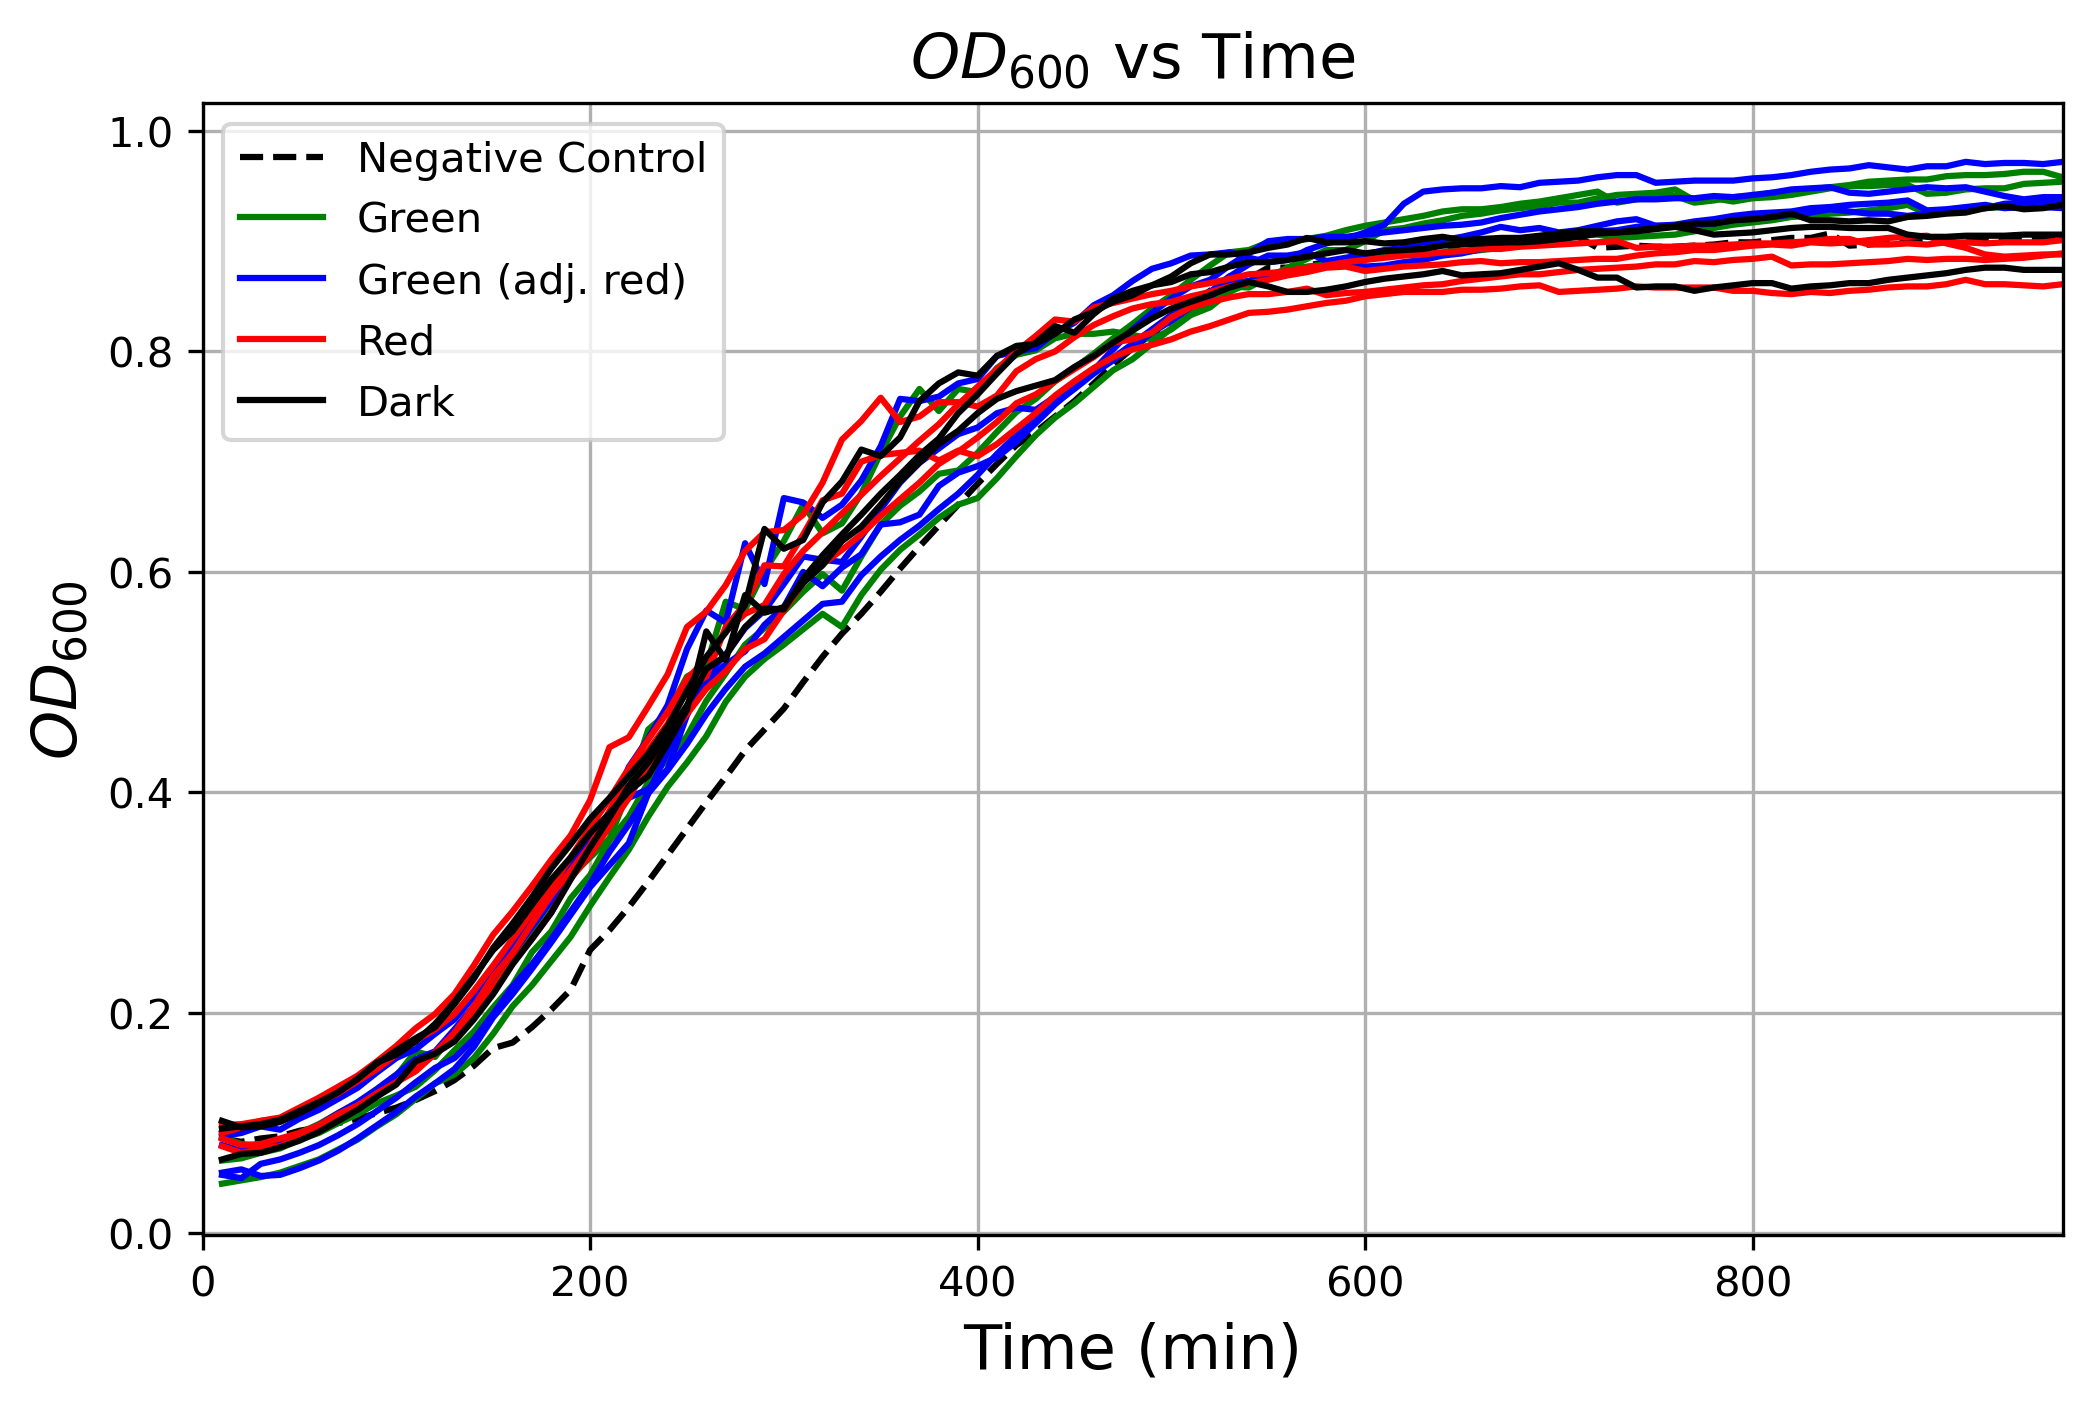

In [6]:
fig, ax = plt.subplots(1,1, figsize = (8,5), dpi=300)

size = 5


for i in range(len(neg_wells)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, neg_ctrl_OD[i, :], '--', color = color_dict['neg_ctrl'], label = 'Negative Control')#, s = size)
    else:
        ax.plot(time, neg_ctrl_OD[i, :], '--', color=color_dict['neg_ctrl'])#, s = size)

for i in range(len(green_constant)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, green_constant_OD[i, :], color = color_dict['green_constant'], label = 'Green')#, s = size)

    else:
        ax.plot(time, green_constant_OD[i, :], color = color_dict['green_constant'])#, s = size)

for i in range(len(green_constant_adj_red)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, green_constant_adj_red_OD[i, :], color = color_dict['red_constant_adj_green'], label = 'Green (adj. red)')#, s = size)

    else:
        ax.plot(time, green_constant_adj_red_OD[i, :], color = color_dict['red_constant_adj_green'])#, s = size)

for i in range(len(red_constant)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, red_constant_OD[i, :], color = color_dict['red_constant'], label = 'Red')#, s = size)

    else:
        ax.plot(time, red_constant_OD[i, :], color = color_dict['red_constant'])#, s = size)

for i in range(len(dark_constant)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, dark_constant_OD[i, :], color = color_dict['dark_constant'], label = 'Dark')#, s = size)

    else:
        ax.plot(time, dark_constant_OD[i, :], color = color_dict['dark_constant'])#, s = size)

ax.legend()
ax.grid(True)
ft = 15
ax.set_ylabel(r'$OD_{600}$', fontsize = ft)
ax.set_xlabel('Time (min)', fontsize = ft)
ax.set_title('$OD_{600}$ vs Time', fontsize = ft)
ax.set_xlim((0, xlimit))

(0.0, 960.0)

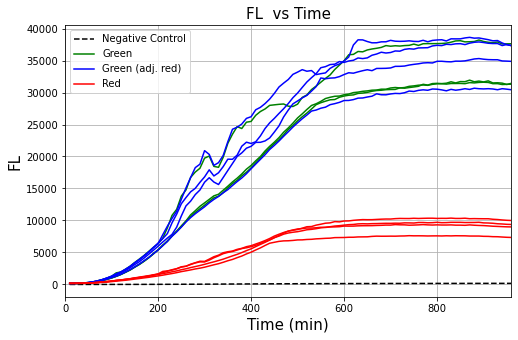

In [7]:
fig, ax = plt.subplots(1,1, figsize = (8,5))

size = 5

for i in range(len(neg_wells)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, neg_ctrl_FL[i, :], '--', color = color_dict['neg_ctrl'], label = 'Negative Control')#, s = size)
    else:
        ax.plot(time, neg_ctrl_FL[i, :], '--', color=color_dict['neg_ctrl'])#, s = size)

for i in range(len(green_constant)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, green_constant_FL[i, :], color = color_dict['green_constant'], label = 'Green')#, s = size)

    else:
        ax.plot(time, green_constant_FL[i, :], color = color_dict['green_constant'])#, s = size)

for i in range(len(green_constant_adj_red)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, green_constant_adj_red_FL[i, :], color = color_dict['red_constant_adj_green'], label = 'Green (adj. red)')#, s = size)

    else:
        ax.plot(time, green_constant_adj_red_FL[i, :], color = color_dict['red_constant_adj_green'])#, s = size)

for i in range(len(red_constant)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, red_constant_FL[i, :], color = color_dict['red_constant'], label = 'Red')#, s = size)

    else:
        ax.plot(time, red_constant_FL[i, :], color = color_dict['red_constant'])#, s = size)


ax.legend()
ax.grid(True)
ft = 15
ax.set_ylabel('FL', fontsize = ft)
ax.set_xlabel('Time (min)', fontsize = ft)
ax.set_title('FL  vs Time', fontsize = ft)
ax.set_xlim((0, xlimit))

(0.0, 960.0)

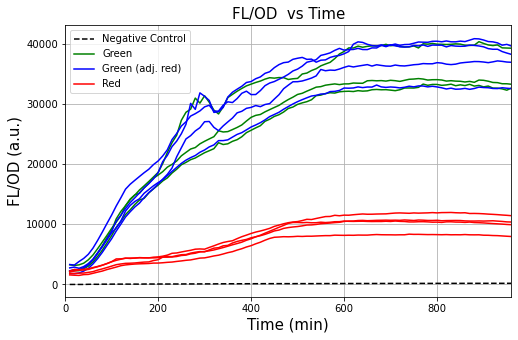

In [8]:
fig, ax = plt.subplots(1,1, figsize = (8,5))

size = 5

for i in range(len(neg_wells)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, neg_ctrl_FL_by_OD[i, :], '--', color = color_dict['neg_ctrl'], label = 'Negative Control')#, s = size)
    else:
        ax.plot(time, neg_ctrl_FL_by_OD[i, :], '--', color=color_dict['neg_ctrl'])#, s = size)

for i in range(len(green_constant)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, green_constant_FL_by_OD[i, :], color = color_dict['green_constant'], label = 'Green')#, s = size)

    else:
        ax.plot(time, green_constant_FL_by_OD[i, :], color = color_dict['green_constant'])#, s = size)

for i in range(len(green_constant_adj_red)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, green_constant_adj_red_FL_by_OD[i, :], color = color_dict['red_constant_adj_green'], label = 'Green (adj. red)')#, s = size)

    else:
        ax.plot(time, green_constant_adj_red_FL_by_OD[i, :], color = color_dict['red_constant_adj_green'])#, s = size)

for i in range(len(red_constant)):
    # Add label only for the first replicate
    if i == 0:
        ax.plot(time, red_constant_FL_by_OD[i, :], color = color_dict['red_constant'], label = 'Red')#, s = size)

    else:
        ax.plot(time, red_constant_FL_by_OD[i, :], color = color_dict['red_constant'])#, s = size)


ax.legend()
ax.grid(True)
ft = 15
ax.set_ylabel('FL/OD (a.u.)', fontsize = ft)
ax.set_xlabel('Time (min)', fontsize = ft)
ax.set_title('FL/OD  vs Time', fontsize = ft)
ax.set_xlim((0, xlimit))

In [9]:
green_constant_adj_red_avg = np.mean(green_constant_adj_red_FL_by_OD, axis = 0)
red_constant_avg = np.mean(red_constant_FL_by_OD, axis = 0)
green_constant_avg = np.mean(green_constant_FL_by_OD, axis = 0)
dark_constant_avg = np.mean(dark_constant_FL_by_OD, axis = 0)


green_constant_adj_red_std_dev = np.std(green_constant_adj_red_FL_by_OD, axis = 0)
red_constant_std_dev = np.std(red_constant_FL_by_OD, axis = 0)
green_constant_std_dev = np.std(green_constant_FL_by_OD, axis = 0)
dark_constant_std_dev = np.std(dark_constant_FL_by_OD, axis = 0)

(0.0, 960.0)

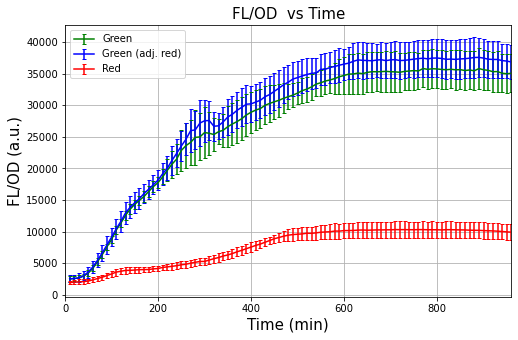

In [10]:
fig, ax = plt.subplots(1,1, figsize = (8,5))

size = 5

ax.errorbar(time, green_constant_avg, yerr = green_constant_std_dev, color = color_dict['green_constant'], label = 'Green', capsize = 2)
ax.errorbar(time, green_constant_adj_red_avg, yerr = green_constant_adj_red_std_dev, color = color_dict['red_constant_adj_green'], label = 'Green (adj. red)', capsize = 2)
ax.errorbar(time, red_constant_avg, yerr = red_constant_std_dev, color = color_dict['red_constant'], label = 'Red', capsize = 2)



ax.legend()
ax.grid(True)
ft = 15
ax.set_ylabel('FL/OD (a.u.)', fontsize = ft)
ax.set_xlabel('Time (min)', fontsize = ft)
ax.set_title('FL/OD  vs Time', fontsize = ft)
ax.set_xlim((0, xlimit))

In [11]:
green_constant_adj_red_avg_OD = np.mean(green_constant_adj_red_OD, axis = 0)
red_constant_avg_OD = np.mean(red_constant_OD, axis = 0)
green_constant_avg_OD = np.mean(green_constant_OD, axis = 0)
dark_constant_avg_OD = np.mean(dark_constant_OD, axis = 0)


green_constant_adj_red_std_dev_OD = np.std(green_constant_adj_red_OD, axis = 0)
red_constant_std_dev_OD = np.std(red_constant_OD, axis = 0)
green_constant_std_dev_OD = np.std(green_constant_OD, axis = 0)
dark_constant_std_dev_OD = np.std(dark_constant_OD, axis = 0)

(0.0, 960.0)

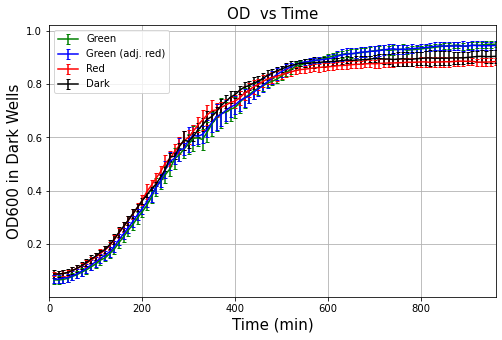

In [12]:
fig, ax = plt.subplots(1,1, figsize = (8,5))

size = 5

ax.errorbar(time, green_constant_avg_OD, yerr = green_constant_std_dev_OD, color = color_dict['green_constant'], label = 'Green', capsize = 2)
ax.errorbar(time, green_constant_adj_red_avg_OD, yerr = green_constant_adj_red_std_dev_OD, color = color_dict['red_constant_adj_green'], label = 'Green (adj. red)', capsize = 2)
ax.errorbar(time, red_constant_avg_OD, yerr = red_constant_std_dev_OD, color = color_dict['red_constant'], label = 'Red', capsize = 2)
ax.errorbar(time, dark_constant_avg_OD, yerr = dark_constant_std_dev_OD, color = color_dict['dark_constant'], label = 'Dark', capsize = 2)



ax.legend()
ax.grid(True)
ft = 15
ax.set_ylabel('OD600 in Dark Wells', fontsize = ft)
ax.set_xlabel('Time (min)', fontsize = ft)
ax.set_title('OD  vs Time', fontsize = ft)
ax.set_xlim((0, xlimit))

In [13]:
# ##Export the FL/OD data for modeling work 

# FL_OD_data = dict()

# FL_OD_data['G1'] = green_constant_FL_by_OD[0]
# FL_OD_data['G2'] = green_constant_FL_by_OD[1]
# FL_OD_data['G3'] = green_constant_FL_by_OD[2]


# FL_OD_data['G1_adj_red'] = green_constant_adj_red_FL_by_OD[0]
# FL_OD_data['G2_adj_red'] = green_constant_adj_red_FL_by_OD[1]
# FL_OD_data['G3_adj_red'] = green_constant_adj_red_FL_by_OD[2]
# FL_OD_data['G4_adj_red'] = green_constant_adj_red_FL_by_OD[3]


# FL_OD_data['R1'] = red_constant_FL_by_OD[0]
# FL_OD_data['R2'] = red_constant_FL_by_OD[1]
# FL_OD_data['R3'] = red_constant_FL_by_OD[2]
# FL_OD_data['R4'] = red_constant_FL_by_OD[3]

# FL_OD_data['D1'] = dark_constant_FL_by_OD[0]
# FL_OD_data['D2'] = dark_constant_FL_by_OD[1]
# FL_OD_data['D3'] = dark_constant_FL_by_OD[2]

# FL_OD_data['NC'] = neg_ctrl_FL_by_OD[0]

# FL_OD_data['Time'] = time

# FL_OD_df = pd.DataFrame(data = FL_OD_data)
# FL_OD_df.to_csv('FL_OD_run_data_031526.csv')


# OD_data = dict()

# OD_data['OD_G1'] = green_constant_OD[0]
# OD_data['OD_G2'] = green_constant_OD[1]
# OD_data['OD_G3'] = green_constant_OD[2]

# OD_data['OD_D1'] = dark_constant_OD[0]
# OD_data['OD_D2'] = dark_constant_OD[1]
# OD_data['OD_D3'] = dark_constant_OD[2]

# OD_data['OD_G1_r'] = green_constant_adj_red_OD[0]
# OD_data['OD_G2_r'] = green_constant_adj_red_OD[1]
# OD_data['OD_G3_r'] = green_constant_adj_red_OD[2]
# OD_data['OD_G4_r'] = green_constant_adj_red_OD[3]


# OD_data['OD_R1'] = red_constant_OD[0]
# OD_data['OD_R2'] = red_constant_OD[1]
# OD_data['OD_R3'] = red_constant_OD[2]
# OD_data['OD_R4'] = red_constant_OD[3]


# OD_data['NC'] = neg_ctrl_FL_by_OD[0]

# OD_data['Time'] = time

# OD_df = pd.DataFrame(data = OD_data)
# OD_df.to_csv('OD_run_data_031526.csv')